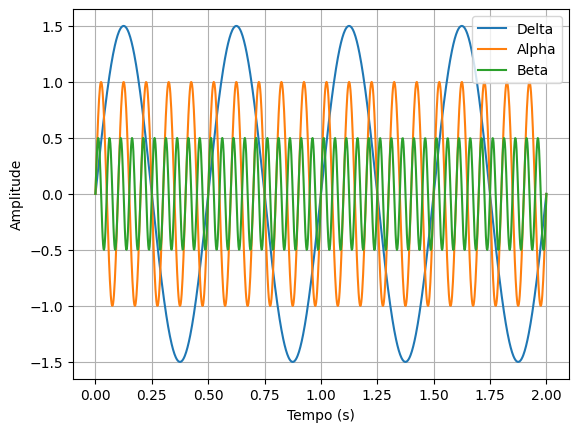

In [10]:
#criação de dados de EEG simulados para teste de algoritmos de análise de sinais
#todos com dois segundos e frequência de amostragem de 1000Hz
# Onda Delta (Sono profundo): Frequência de 2 Hz, Amplitude de 1.5
import numpy as np
import matplotlib.pyplot as plt

t=np.linspace(0,2,1000) # vetor tempo de 2 segundos com 1000 amostras, np.linspace(inicio, fim, numero de amostras)
fd=2 #frequência da onda delta
delta=1.5*np.sin(2*np.pi*fd*t) #onda delta sin(2pi*frequencia*t)
fig, ax=plt.subplots()
ax.plot(t,delta, label='Delta') #plota onda delta
ax.legend(loc='upper right')
ax.grid(True)
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
#Onda Alpha (Relaxado): Frequência de 10 Hz, Amplitude de 1.0
fa=10 #frequência da onda alpha
alpha=1.0*np.sin(2*np.pi*fa*t) #onda alpha sin(2pi*frequencia*t)
ax.plot(t,alpha, label='Alpha') #plota onda alpha
ax.legend(loc='upper right')
#Onda Beta (Focado/Alerta): Frequência de 20 Hz, Amplitude de 0.5
fb=20 #frequência da onda beta
beta=0.5*np.sin(2*np.pi*fb*t) #onda beta sin(2pi*frequencia*t)
ax.plot(t,beta, label='Beta') #plot onda beta
ax.legend(loc='upper right')

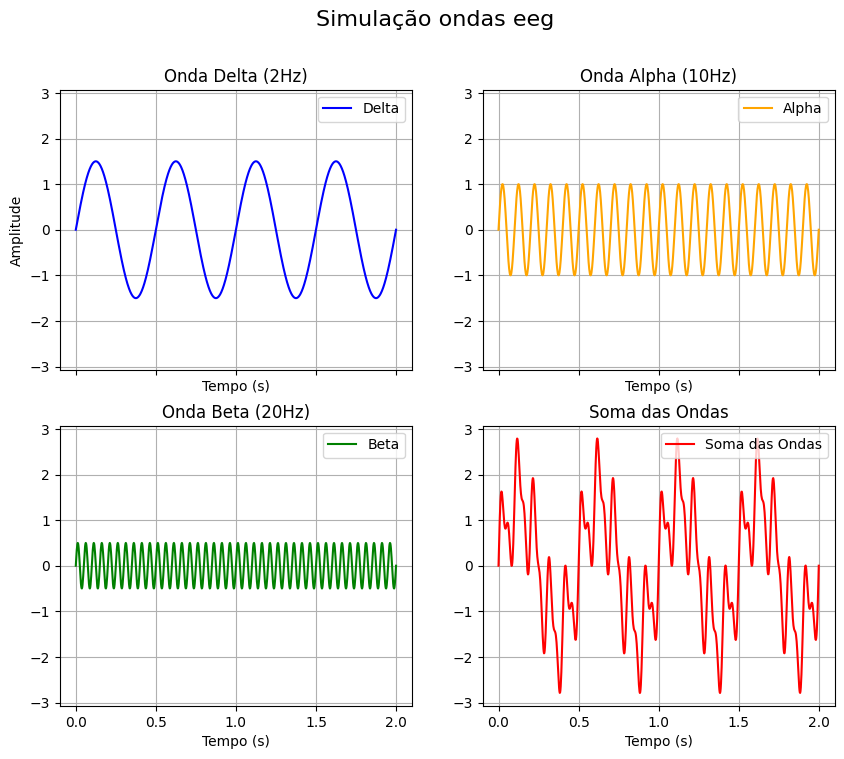

In [11]:
# explorando subplots para separar as ondas em gráficos diferentes e posteriormente somar todas as ondas em um único gráfico
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
fig.suptitle('Simulação ondas eeg', fontsize=16)
#onda delta
axs[0, 0].plot(t, delta, label='Delta', color='blue') #da matriz 2x2 esse grafico fica na posição 0,0
axs[0, 0].set_title('Onda Delta (2Hz)')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].set_xlabel('Tempo (s)')
axs[0, 0].grid(True)
axs[0,0].legend(loc='upper right')
axs[0,0].sharey(axs[1,1]) #compartilha eixo y com o grafico da soma das ondas
#onda alpha
axs[0,1].plot(t, alpha, label='Alpha', color='orange') #da matriz 2x2 esse grafico fica na posição 0,1
axs[0,1].set_title('Onda Alpha (10Hz)')
axs[0,1].set_xlabel('Tempo (s)')
axs[0,1].grid(True)
axs[0,1].legend(loc='upper right')
axs[0,1].sharey(axs[1,1]) #compartilha eixo y com o grafico da soma das ondas
#onda beta
axs[1,0].plot(t, beta, label='Beta', color='green')
axs[1,0].set_title('Onda Beta (20Hz)')
axs[1,0].set_xlabel('Tempo (s)')
axs[1,0].grid(True)
axs[1,0].legend(loc='upper right')
axs[1,0].sharey(axs[1,1]) #compartilha eixo y com o grafico da soma das ondas

#soma das ondas
soma_ondas = delta + alpha + beta

axs[1,1].plot(t, soma_ondas, label='Soma das Ondas', color='red')
axs[1,1].set_title('Soma das Ondas')
axs[1,1].set_xlabel('Tempo (s)')    
axs[1,1].grid(True)
axs[1,1].legend(loc='upper right')

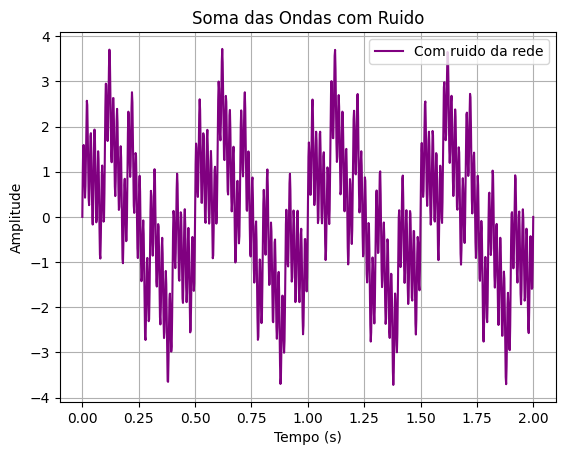

In [12]:
#criando ruidos no sinal
rede=np.sin(2*np.pi*60*t) #ruido de 60Hz da rede elétrica
soma_ondas_ruido=soma_ondas + rede #soma do sinal com o ruido

fig2, ax2 = plt.subplots()
ax2.plot(t, soma_ondas_ruido, label='Com ruido da rede', color='purple')
ax2.set_title('Soma das Ondas com Ruido')
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('Amplitude')
ax2.grid(True)
ax2.legend(loc='upper right')
ax2.grid(True)

In [ ]:
#adicionando dicionários para classificar pacientes com base nas ondas predominantes

paciente1={'nome': 'Zé Tião', 'idade': '41', 'sexo': 'M', 'predominante': 'Delta', 'frequência': fd}
paciente2={'nome': 'Gilsa', 'idade': '35', 'sexo': 'F', 'predominante': 'Alpha', 'frequência': fa}
paciente3={'nome': 'Homer Simpson', 'idade': '28', 'sexo': 'M', 'predominante': 'Beta', 'frequência': fb}
paciente4={'nome': 'Vanessa', 'idade': '22', 'sexo': 'F', 'predominante': 'Delta', 'frequência': fd}
paciente5={'nome': 'Hitaro', 'idade': '17', 'sexo': 'M', 'predominante': 'Beta', 'frequência': fb}

def classificar_paciente(paciente): # criando funcção para classificar o paciente de acordo com a frequêcia dominante
    if paciente['frequência'] < 4:
        paciente['estado'] = 'sono profundo'
    elif paciente['frequência'] >= 4 and paciente['frequência'] < 8:
        paciente['estado'] = 'sono leve'
    elif paciente['frequência'] >=8 and paciente['frequência']<13:
        paciente['estado']= 'relaxado'
    else:
        paciente['estado']= 'alerta ou focado'

classificar_paciente(paciente1) #utilizando a função para classificar o paciente 1
classificar_paciente(paciente2) #utilizando a função para classificar o paciente 2
classificar_paciente(paciente3) #utilizando a função para classificar o paciente 3
classificar_paciente(paciente4) #utilizando a função para classificar o paciente 4
classificar_paciente(paciente5) #utilizando a função para classificar o paciente 5

print(f"O paciente 1 {paciente1['nome']} possui a onda {paciente1['predominante']} como predominante, o que indica que ele está em estado de {paciente1['estado']}")
print(f"O paciente 2 {paciente2['nome']} possui a onda {paciente2['predominante']} como predominante, o que indica que ele está em estado de {paciente2['estado']}")
print(f"O paciente 3 {paciente3['nome']} possui a onda {paciente3['predominante']} como predominante, o que indica que ele está em estado de {paciente3['estado']}")
print(f"O paciente 4 {paciente4['nome']} possui a onda {paciente4['predominante']} como predominante, o que indica que ele está em estado de {paciente4['estado']}")
print(f"O paciente 5 {paciente5['nome']} possui a onda {paciente5['predominante']} como predominante, o que indica que ele está em estado de {paciente5['estado']}")


O paciente 1 Zé Tião possui a onda Delta como predominante, o que indica que ele está em estado de sono profundo
O paciente 2 Gilsa possui a onda Alpha como predominante, o que indica que ele está em estado de relaxado
O paciente 3 Homer Simpson possui a onda Beta como predominante, o que indica que ele está em estado de alerta ou focado
O paciente 4 Vanessa possui a onda Delta como predominante, o que indica que ele está em estado de sono profundo


In [ ]:
#criando base de dados com pandas para armazenar os pacientes e suas classificações
import pandas as pd

df=pd.DataFrame([paciente1, paciente2, paciente3, paciente4, paciente5]) #criando um dataframe com os pacientes
df=df.sort_values(by="frequência") #ordenando o dataframe pela frequência
df

,nome,idade,sexo,predominante,frequência,estado
0,Zé Tião,41,M,Delta,2,sono profundo
3,Vanessa,22,F,Delta,2,sono profundo
1,Gilsa,35,F,Alpha,10,relaxado
2,Homer Simpson,28,M,Beta,20,alerta ou focado
